# Introduction

This notebook focuses on movies released between 1990 and 1999.
The goal is to explore trends in the 1990s using the cleaned Netflix dataset.

We will look at:
- how many movies were released each year
- which genres were most common
- duration patterns
- which countries produced the most content
- top directors

All reusable logic (filtering, grouping, plotting) comes from the scripts
in the `scripts/` folder to keep this notebook clean.


# Imports & Setup

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure project root is set
project_root = os.path.abspath("..")

# Add project root to Python path
sys.path.insert(0, project_root)

# Create a helper to auto‑save visuals
visuals_dir = os.path.join(project_root, "visuals")
os.makedirs(visuals_dir, exist_ok=True)

def save_visual(filename):
    return os.path.join(visuals_dir, filename)


# Import Helper Functions

In [9]:
# import EDA and visualization helpers
from scripts.eda_utils import (
    filter_movies,
    filter_1990s,
    movies_per_year,
    top_genres,
    avg_duration_by_genre,
    country_counts,
    top_directors,
    filter_non_1990s,
    compare_avg_duration,
    compare_genre_distribution
    
)

from scripts.visualization_utils import (
    plot_movies_per_year,
    plot_top_genres,
    plot_avg_duration,
    plot_country_counts,
    plot_duration_distribution,
    plot_genre_comparison,
    plot_duration_comparison
)

# Load Cleaned Dataset

In [10]:
cleaned_path = os.path.join(project_root, "data", "processed", "netflix_cleaned.csv")

df = pd.read_csv(cleaned_path)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,year_added,duration_type,decade
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,93,After a devastating earthquake hits Mexico Cit...,Dramas,2016.0,min,2010
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,78,"When an army recruit is found dead, his fellow...",Horror Movies,2018.0,min,2010
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action,2017.0,min,2000
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,123,A brilliant group of students become card-coun...,Dramas,2020.0,min,2000
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,1,A genetics professor experiments with a treatm...,International TV,2017.0,Seasons,2010


# Filter for 1990s Movies

In [11]:
movies_df = filter_movies(df)
movies_1990s = filter_1990s(movies_df)

movies_1990s.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre,year_added,duration_type,decade
6,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,2019-11-01,1997,119,After one of his high school students attacks ...,Dramas,2019.0,min,1990
118,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,2018-04-01,1993,101,At the center of this engrossing melodrama is ...,Dramas,2018.0,min,1990
145,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,2019-12-01,1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies,2019.0,min,1990
167,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,2020-12-01,1996,108,When a philandering club promoter sets out to ...,Comedies,2020.0,min,1990
194,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,2017-06-01,1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas,2017.0,min,1990


### Quick notes
- We are only analyzing movies (not TV shows).
- The 1990s subset is based on `release_year` between 1990 and 1999.

# Movies Released per Year (1990–1999)

In [12]:
year_counts = movies_per_year(movies_1990s)
year_counts

,release_year,count
0,1990,14
1,1991,14
2,1992,16
3,1993,16
4,1994,14
5,1995,16
6,1996,15
7,1997,26
8,1998,26
9,1999,26


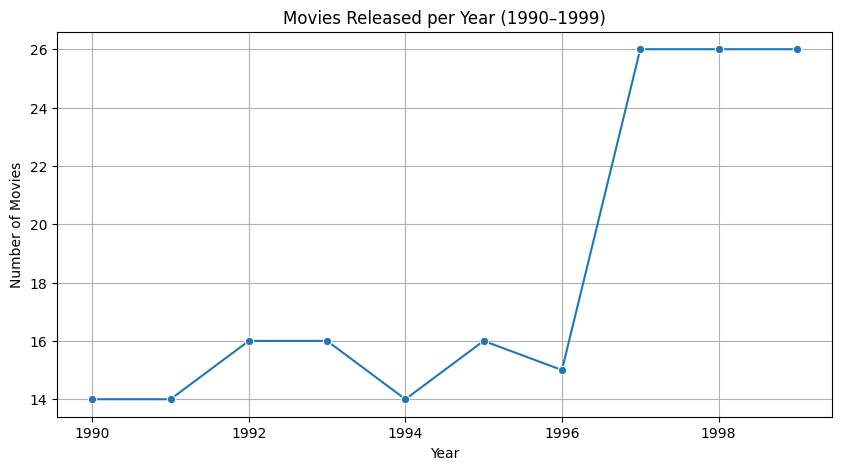

In [13]:
plot_movies_per_year(
    year_counts,
    title="Movies Released per Year (1990–1999)",
    save_path=save_visual("1990s_movies_per_year.png")
)

# Top Genres in the 1990s

In [14]:
genres_1990s = top_genres(movies_1990s, n=10)
genres_1990s

,genre,count
0,Action,48
1,Dramas,44
2,Comedies,40
3,Children,15
4,Classic Movies,15
5,Stand-Up,8
6,Thrillers,5
7,Horror Movies,4
8,Documentaries,2
9,Cult Movies,2


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="genre", palette="viridis")


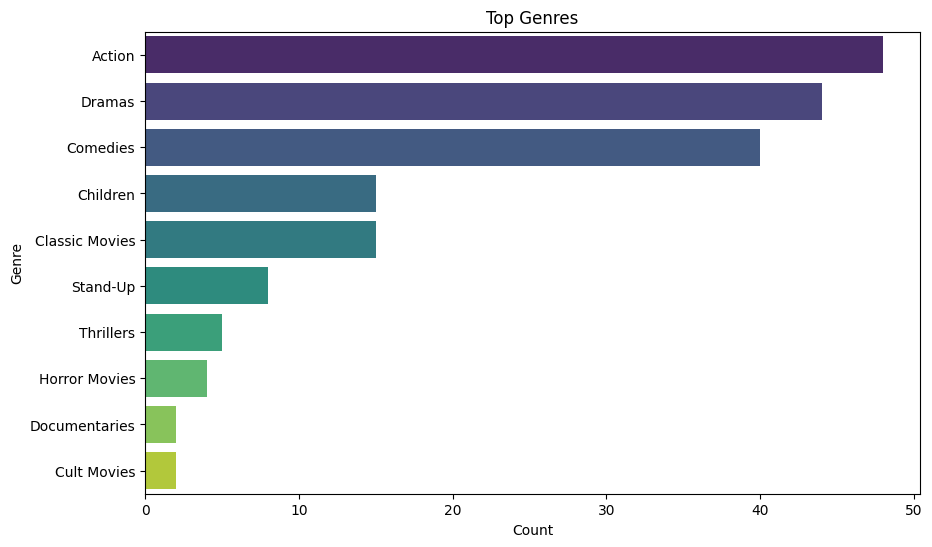

In [15]:
plot_top_genres(
    genres_1990s,
    save_path=save_visual("top_genres_1990s.png")
)

# Average Duration by Genre

In [16]:
duration_stats = avg_duration_by_genre(movies_1990s)
duration_stats

,genre,duration
6,Dramas,132.045455
2,Classic Movies,128.733333
0,Action,120.145833
3,Comedies,110.700000
9,Thrillers,109.200000
7,Horror Movies,104.750000
4,Cult Movies,100.000000
1,Children,93.066667
5,Documentaries,72.000000
8,Stand-Up,53.250000


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="duration", y="genre", palette="magma")


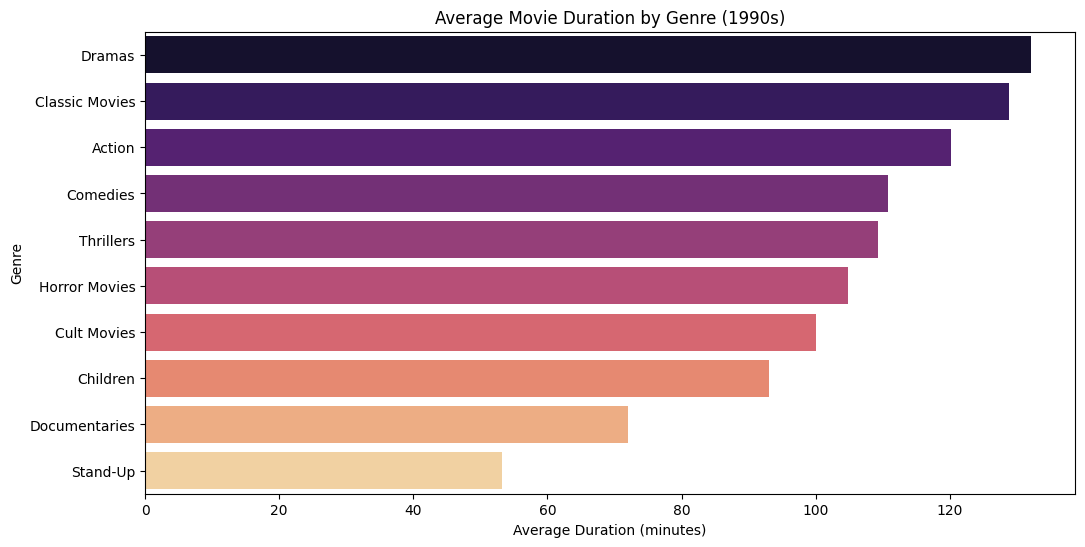

In [17]:
plot_avg_duration (
    duration_stats,
    title="Average Movie Duration by Genre (1990s)",
    save_path= save_visual("avg_duration_by_genre_1990s.png")
)

# Top Countries Producing Movies in the 1990s

In [18]:
countries_1990s = country_counts(movies_1990s, n=10)
countries_1990s

,country,count
0,United States,99
1,India,34
2,United Kingdom,17
3,Hong Kong,11
4,France,5
5,Australia,5
6,Mexico,3
7,Germany,2
8,Japan,2
9,Poland,1


c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="country", palette="cubehelix")


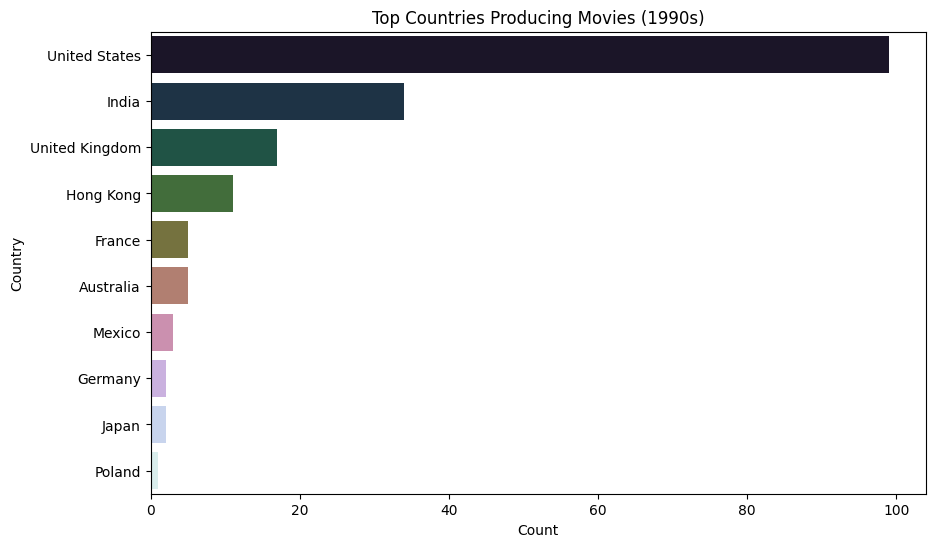

In [19]:
plot_country_counts(
    countries_1990s,
    title="Top Countries Producing Movies (1990s)",
    save_path=save_visual("country_production_1990s.png")
)

# Top Directors in the 1990s

In [20]:
directors_1990s = top_directors(movies_1990s, n=10)
directors_1990s

,count,count
0,Johnnie To,4
1,Umesh Mehra,3
2,Rajkumar Santoshi,3
3,Mahesh Bhatt,3
4,Gregory Hoblit,3
5,Youssef Chahine,3
6,Sooraj R. Barjatya,3
7,Subhash Ghai,3
8,John Fortenberry,2
9,Mukul Anand,2


# Duration Distribution

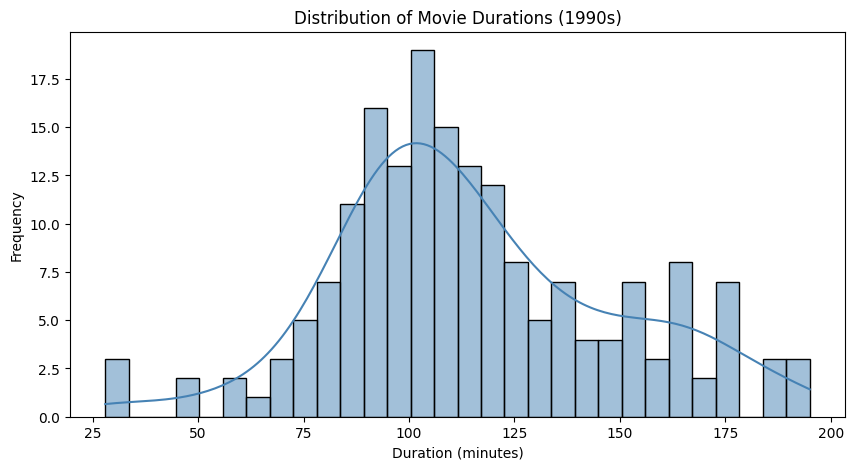

In [21]:
plot_duration_distribution(
    movies_1990s,
    title="Distribution of Movie Durations (1990s)",
    save_path=save_visual("duration_distribution_1990s.png")
)

# Comparing 1990s Movies vs. Other Movies

# Filter both groups

In [22]:

other_movies = filter_non_1990s(movies_df)

# Compare average duration

In [23]:
duration_compare = compare_avg_duration(movies_1990s, other_movies)
duration_compare


{'1990s_avg_duration': np.float64(115.12021857923497),
 'other_avg_duration': np.float64(101.86604361370716)}

c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette="coolwarm")


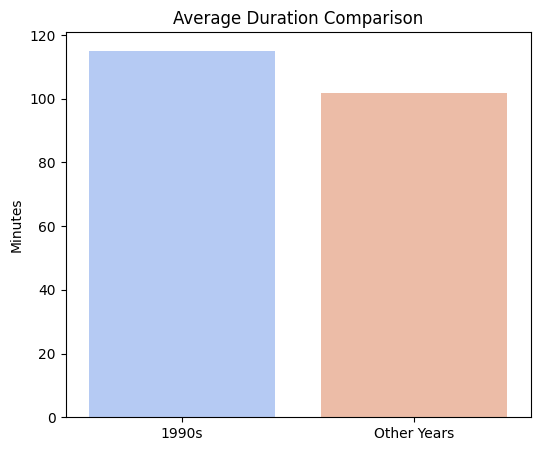

In [24]:
plot_duration_comparison(
    duration_compare,
    save_path=save_visual("duration_comparison_1990s_vs_others.png")
)

# Compare genre distribution

In [25]:
genres_90s, genres_other = compare_genre_distribution(movies_1990s, other_movies)
genres_90s, genres_other

(genre
 Action            48
 Dramas            44
 Comedies          40
 Children          15
 Classic Movies    15
 Stand-Up           8
 Thrillers          5
 Horror Movies      4
 Documentaries      2
 Cult Movies        2
 Name: count, dtype: int64,
 genre
 Dramas                  1299
 Comedies                 989
 Action                   648
 Children                 406
 Documentaries            350
 Stand-Up                 268
 Horror Movies            235
 International Movies     100
 Classic Movies            54
 Thrillers                 44
 Name: count, dtype: int64)

c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_90s.values, y=genre_90s.index, palette="viridis")
c:\Users\olayi\OneDrive\Desktop\Data\python-projects\projects\netflix-analysis-project\scripts\visualization_utils.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_other.values, y=genre_other.index, palette="magma")


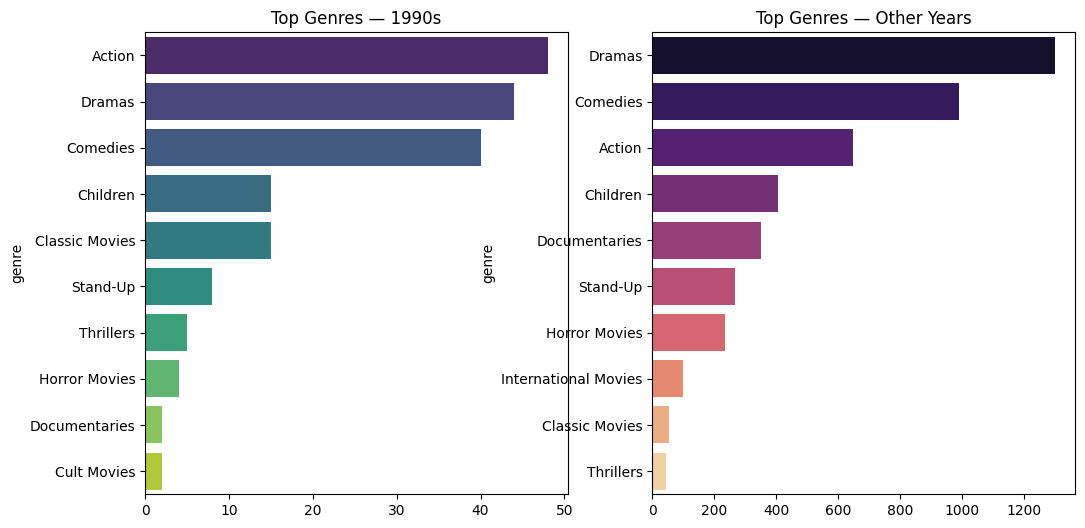

In [26]:
plot_genre_comparison(
    genres_90s,
    genres_other,
    save_path=save_visual("genre_comparison_1990s_vs_others.png")
)

# Compare country contributions

In [27]:
countries_90s = country_counts(movies_1990s, n=10)
countries_other = country_counts(other_movies, n=10)

countries_90s, countries_other


(          country  count
 0   United States     99
 1           India     34
 2  United Kingdom     17
 3       Hong Kong     11
 4          France      5
 5       Australia      5
 6          Mexico      3
 7         Germany      2
 8           Japan      2
 9          Poland      1,
           country  count
 0   United States   1757
 1           India    824
 2  United Kingdom    272
 3          Canada    150
 4          France    124
 5           Spain    105
 6           Egypt     90
 7          Turkey     76
 8     Philippines     74
 9       Indonesia     73)

# Compare directors

In [28]:
directors_90s = top_directors(movies_1990s, n=10)
directors_other = top_directors(other_movies, n=10)

directors_90s, directors_other

(                count  count
 0          Johnnie To      4
 1         Umesh Mehra      3
 2   Rajkumar Santoshi      3
 3        Mahesh Bhatt      3
 4      Gregory Hoblit      3
 5     Youssef Chahine      3
 6  Sooraj R. Barjatya      3
 7        Subhash Ghai      3
 8    John Fortenberry      2
 9         Mukul Anand      2,
                     count  count
 0  Raúl Campos, Jan Suter     18
 1               Jay Karas     14
 2            Marcus Raboy     14
 3     Cathy Garcia-Molina     13
 4             Jay Chapman     12
 5         Martin Scorsese     11
 6         Youssef Chahine      9
 7             Hakan Algül      8
 8         Shannon Hartman      8
 9        Steven Spielberg      8)

# Summary of Findings

### Key Insights from the 1990s

- Movie output stayed low until 1997, then doubled and remained high through 1999.

- Action, Drama, and Comedy dominate the decade.

- The typical runtime is ~100 minutes, with Dramas being the longest.

- The United States overwhelmingly leads production, followed by India and the UK.

- A small set of directors appear frequently, indicating a more concentrated creative landscape.

### Summary: 1990s vs. Other Movies

- 1990s movies are longer (115 min vs 102 min).

- The 1990s have fewer genres, focused on mainstream categories.

- Other decades show greater genre diversity, including niche and international categories.

- Country contributions in the 1990s are dominated by the US, while other years show broader global participation.

- Director patterns differ: the 1990s have recurring names, while other years are more dispersed.

- These comparisons help highlight what made the 1990s distinct.

The 1990s on Netflix represent a concentrated, mainstream, US‑heavy era with longer films and fewer niche genres — very different from the more global, diverse, and experimental patterns seen in other decades.
